In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import warnings

# 1. 關閉警告訊息並設定中文字體
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 讀取原始資料
df = pd.read_csv('../data/raw/YRBS_2007.csv')

Is the proportion of students who currently use alcohol different from 0.35?

目前飲酒學生的比例是否與 0.35 不同？

Is the mean weight of students different from 68.0 kg?

學生的平均體重與 68.0 公斤有差異嗎？

【4.3 EDA - 變數定義與原始資料分配】
分析變數：CurrentAlcoholUse (過去30天飲酒天數)
------------------------------
代碼含義說明 (Codebook Definition):
1: 0 天 (0 days)
2: 1 或 2 天 (1 or 2 days)
3: 3 到 5 天 (3 to 5 days)
4: 6 到 9 天 (6 to 9 days)
5: 10 到 19 天 (10 to 19 days)
6: 20 到 29 天 (20 to 29 days)
7: 所有 30 天 (All 30 days)
------------------------------
有效代碼次數分配 (Valid Code Counts):
CurrentAlcoholUse
1.0    6946
2.0    2735
3.0    1369
4.0     839
5.0     555
6.0     105
7.0     120
Name: count, dtype: int64

缺失值數量 (Missing/Invalid): 1372


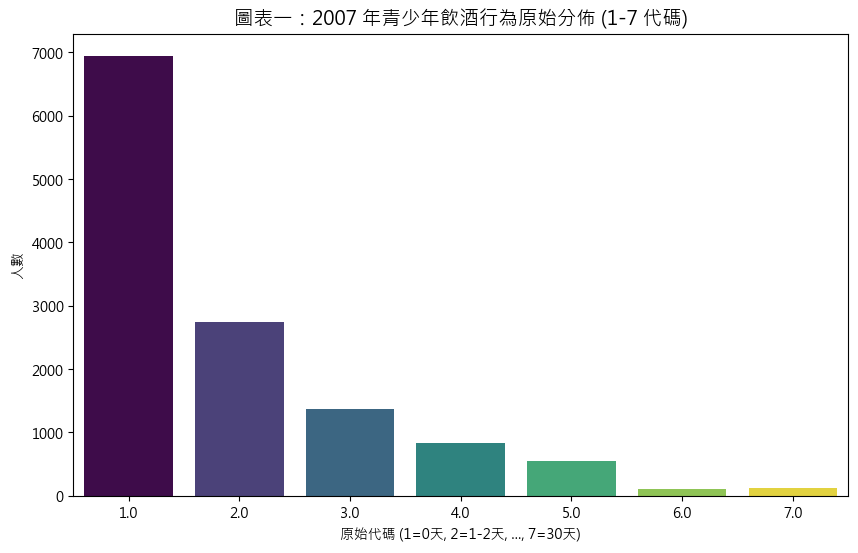

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# --- 1. 資料清理與缺失值檢查 (Missing Count) ---
missing_alc = df['CurrentAlcoholUse'].isna().sum()
df_alc_raw = df.dropna(subset=['CurrentAlcoholUse']).copy()
n_alc = len(df_alc_raw)

# --- 2. 原始代碼頻率表與變數定義說明 ---
print("="*50)
print("【4.3 EDA - 變數定義與原始資料分配】")
print(f"分析變數：CurrentAlcoholUse (過去30天飲酒天數)")
print("-" * 30)
print("代碼含義說明 (Codebook Definition):")
print("1: 0 天 (0 days)")
print("2: 1 或 2 天 (1 or 2 days)")
print("3: 3 到 5 天 (3 to 5 days)")
print("4: 6 到 9 天 (6 to 9 days)")
print("5: 10 到 19 天 (10 to 19 days)")
print("6: 20 到 29 天 (20 to 29 days)")
print("7: 所有 30 天 (All 30 days)")
print("-" * 30)

# 印出實際的人數分佈
print("有效代碼次數分配 (Valid Code Counts):")
raw_counts = df_alc_raw['CurrentAlcoholUse'].value_counts().sort_index()
print(raw_counts)
print(f"\n缺失值數量 (Missing/Invalid): {missing_alc}")
print("="*50)

# --- 3. 繪圖一：原始類別分佈圖 (Display 1: Bar chart of original categories) ---
plt.figure(figsize=(10, 6))
sns.countplot(x='CurrentAlcoholUse', data=df_alc_raw, palette='viridis', hue='CurrentAlcoholUse', legend=False)
plt.title('圖表一：2007 年青少年飲酒行為原始分佈 (1-7 代碼)', fontsize=14)
plt.xlabel('原始代碼 (1=0天, 2=1-2天, ..., 7=30天)')
plt.ylabel('人數')
plt.savefig('../outputs/figures/alcohol_original_dist.png')
plt.show()



【4.3 EDA - 二元重編碼邏輯與對照表】
重編碼規則說明 (Recoding Rules):
- 原始代碼 1 (0天) ----------> 失敗 (0: Failure)
- 原始代碼 2-7 (1天以上) ----> 成功 (1: Success)
------------------------------
二元化對照矩陣 (Recoding Crosstab):
alcohol_binary        0     1     總計
CurrentAlcoholUse                   
1.0                6946     0   6946
2.0                   0  2735   2735
3.0                   0  1369   1369
4.0                   0   839    839
5.0                   0   555    555
6.0                   0   105    105
7.0                   0   120    120
總計                 6946  5723  12669


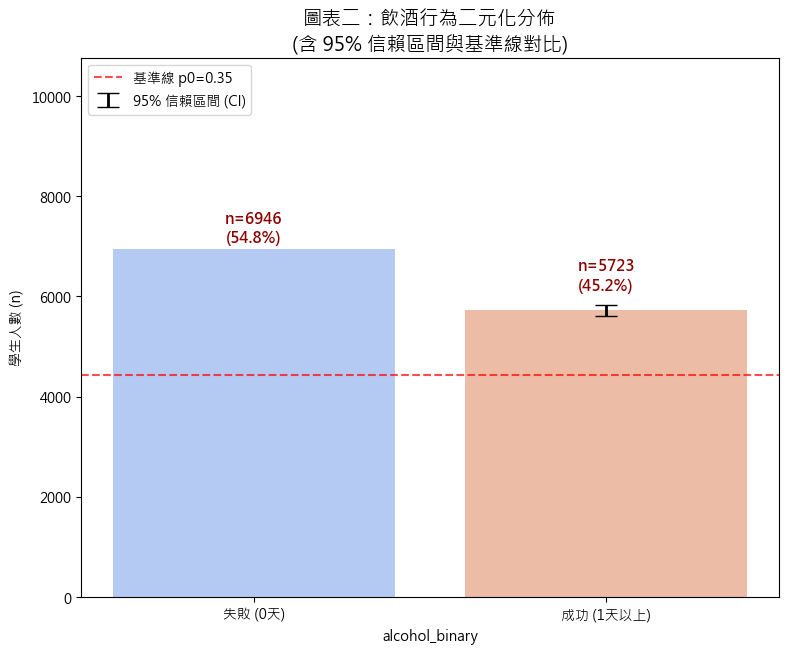

【分析變數：CurrentAlcoholUse (飲酒行為)】
1. 有效樣本總數 (n): 12669
2. 成功次數 (Success): 5723
1. 樣本比例 (p-hat): 0.4517
2. 基準比例 (p0): 0.35
3. 95% 信賴區間: [0.4431, 0.4604]
4. Z 檢定結果: Z=23.0088, P值=3.8041e-117

【4.6 分析觀察報告 (Observations)】
1. 變數與代碼說明：使用 YRBS 變數 'CurrentAlcoholUse'。
   - 有效原始代碼 (Valid Codes): 1, 2, 3, 4, 5, 6, 7
   - 重編碼邏輯: 代碼 1 (0天) -> Failure (0); 代碼 2-7 (1天以上) -> Success (1)
1. 數據清理說明：變數 'CurrentAlcoholUse' 共有 1372 筆缺失值，已在分析前予以排除，確保樣本有效性。
2. 圖表觀察：圖表一顯示原始代碼分佈，圖表二顯示重編碼後之 Success/Failure 分佈。
3. 統計結論：2007 年青少年飲酒比例顯著高於 0.35。


In [14]:
# --- 4. 二元重編碼與對照說明 (Binary Recoding and Crosstab) ---
print("="*50)
print("【4.3 EDA - 二元重編碼邏輯與對照表】")
print("重編碼規則說明 (Recoding Rules):")
print("- 原始代碼 1 (0天) ----------> 失敗 (0: Failure)")
print("- 原始代碼 2-7 (1天以上) ----> 成功 (1: Success)")
print("-" * 30)

# 執行二元轉換
df_alc_raw['alcohol_binary'] = df_alc_raw['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else 0)

# 產生對照表 (Crosstab) 用於驗證
recode_summary = pd.crosstab(
    df_alc_raw['CurrentAlcoholUse'], 
    df_alc_raw['alcohol_binary'],
    margins=True,          # 加上 Total 欄位
    margins_name="總計"
)

print("二元化對照矩陣 (Recoding Crosstab):")
print(recode_summary)
print("="*50)
# --- 5. 繪圖二：二元化分佈圖 (含比例、人數與 95% 信賴區間) ---
plt.figure(figsize=(9, 7))
ax = sns.countplot(x='alcohol_binary', data=df_alc_raw, hue='alcohol_binary', palette='coolwarm', legend=False)

# 1. 準備信賴區間數據 (將比例轉換為人數)
# 假設 ci_low, ci_upp 已經在 Step 6 計算好
ci_low_n = ci_low * n_alc
ci_upp_n = ci_upp * n_alc
y_err = [[count_success - ci_low_n], [ci_upp_n - count_success]] # 計算上下誤差量

# 2. 在「成功 (1)」的長條上繪製誤差棒 (Error Bar)
plt.errorbar(x=1, y=count_success, yerr=y_err, fmt='none', c='black', 
             capsize=8, elinewidth=2, label='95% 信賴區間 (CI)')

# 3. 在長條上方加上百分比與人數標籤
total_n = len(df_alc_raw)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total_n:.1f}%'
    ax.annotate(f'n={int(height)}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 25) if p.get_x() > 0.5 else (0, 15), # 為成功組預留誤差棒空間
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='darkred')

# 4. 繪製基準線
plt.axhline(y=total_n * 0.35, color='red', linestyle='--', label='基準線 p0=0.35', alpha=0.7)

plt.title('圖表二：飲酒行為二元化分佈\n(含 95% 信賴區間與基準線對比)', fontsize=14)
plt.xticks([0, 1], ['失敗 (0天)', '成功 (1天以上)'])
plt.ylabel('學生人數 (n)')
plt.ylim(0, total_n * 0.85) # 再次調高頂部空間防止標籤被切掉
plt.legend(loc='upper left')
plt.savefig('../outputs/figures/alcohol_binary_final_with_CI.png')
plt.show()

# --- 6. 統計推論  ---
count_success = df_alc_raw['alcohol_binary'].sum()
p_hat_alc = count_success / n_alc
z_stat, p_val_alc = proportions_ztest(count_success, n_alc, value=0.35)
ci_low, ci_upp = proportion_confint(count_success, n_alc, alpha=0.05, method='normal')

# --- 7. 輸出結果與書面觀察  ---
print("="*50)
print(f"【分析變數：CurrentAlcoholUse (飲酒行為)】") 
print("="*50)
print(f"1. 有效樣本總數 (n): {n_alc}")
print(f"2. 成功次數 (Success): {count_success}")
print(f"1. 樣本比例 (p-hat): {p_hat_alc:.4f}")
print(f"2. 基準比例 (p0): 0.35")
print(f"3. 95% 信賴區間: [{ci_low:.4f}, {ci_upp:.4f}]")
print(f"4. Z 檢定結果: Z={z_stat:.4f}, P值={p_val_alc:.4e}")
print("="*50)
print("\n【4.6 分析觀察報告 (Observations)】")
print(f"1. 變數與代碼說明：使用 YRBS 變數 'CurrentAlcoholUse'。")
print(f"   - 有效原始代碼 (Valid Codes): 1, 2, 3, 4, 5, 6, 7")
print(f"   - 重編碼邏輯: 代碼 1 (0天) -> Failure (0); 代碼 2-7 (1天以上) -> Success (1)")
print(f"1. 數據清理說明：變數 'CurrentAlcoholUse' 共有 {missing_alc} 筆缺失值，已在分析前予以排除，確保樣本有效性。")
print(f"2. 圖表觀察：圖表一顯示原始代碼分佈，圖表二顯示重編碼後之 Success/Failure 分佈。")
print(f"3. 統計結論：2007 年青少年飲酒比例顯著高於 0.35。")

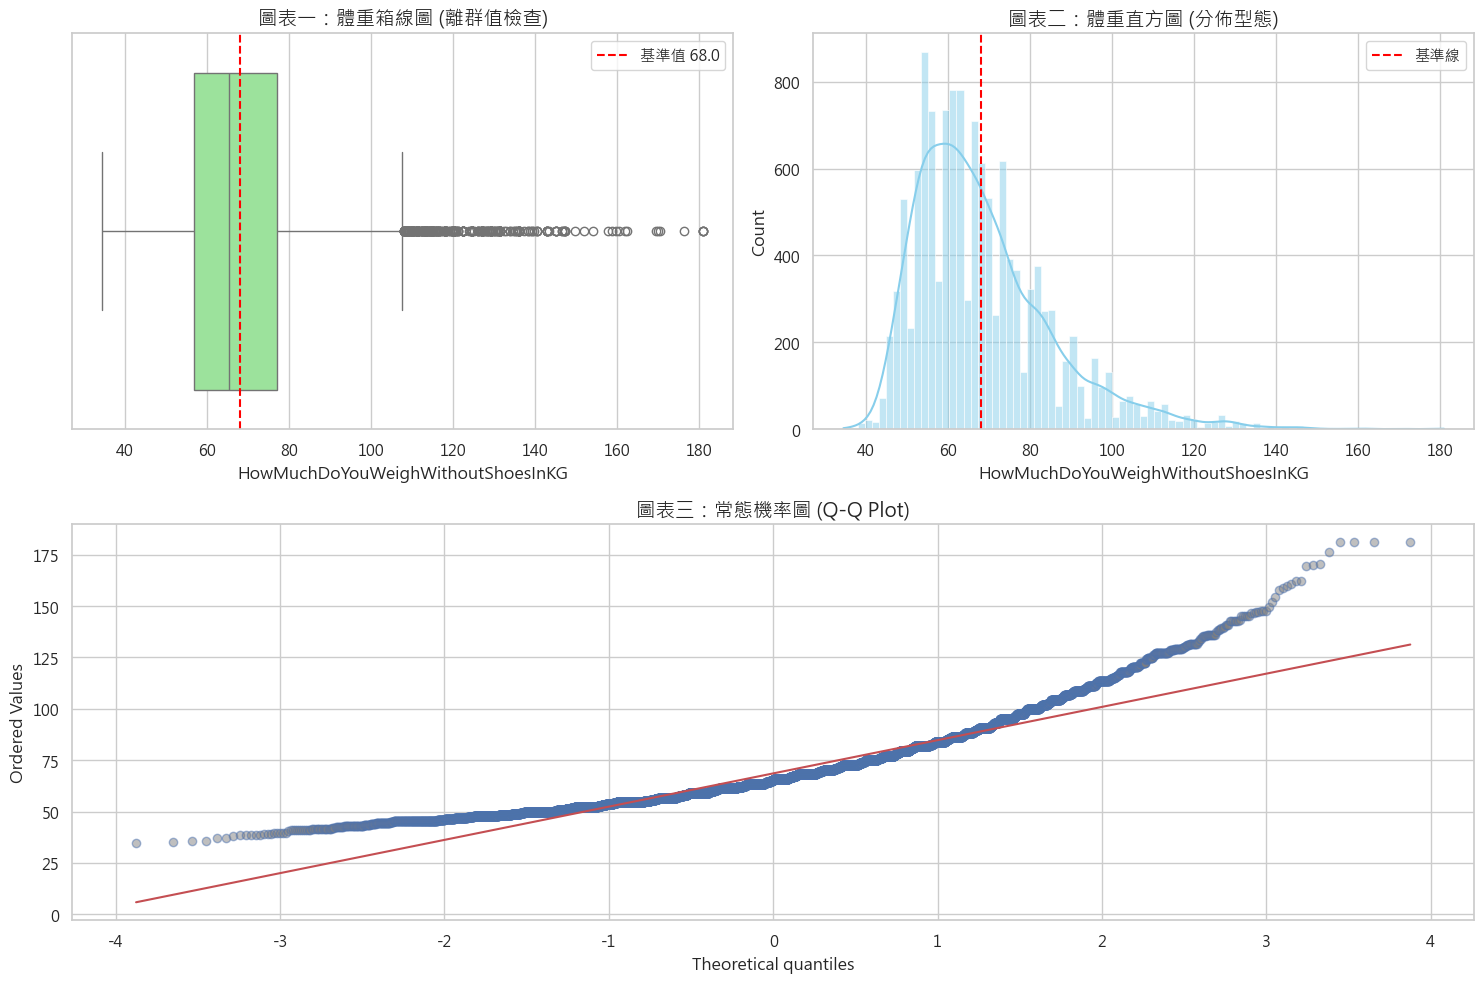

【4.3 & 4.4 體重數據分析總表 - 三圖驗證版】
樣本數: 13062 | 缺失值: 979
平均值: 68.55 | 中位數: 65.32 | 標準差: 16.99
四分位數: Q1=56.70, Q3=77.11
P 值: 2.1586e-04 | 95% CI: [68.26, 68.84]

【4.6 分析觀察報告 (Observations)】
1. 圖表觀察：箱線圖顯示存在多個高體重離群值；直方圖呈現輕微右偏分佈。
2. 假設驗證：Q-Q 圖顯示資料點大致沿著對角線分佈，雖有端點偏離，但樣本數大，T檢定仍具效力。
3. 統計結論：由於 P 值 < 0.05，拒絕虛無假設。2007 年青少年平均體重顯著不同於 68.0 kg。
--------------------------------------------------


In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- 1. 資料清理與缺失值檢查 (Missing Count) ---
missing_weight = df['HowMuchDoYouWeighWithoutShoesInKG'].isna().sum()
df_weight = df.dropna(subset=['HowMuchDoYouWeighWithoutShoesInKG']).copy()
weights = df_weight['HowMuchDoYouWeighWithoutShoesInKG']
n_w = len(weights)

# --- 2. 描述性統計 (Summary Statistics: mean, median, std, quartiles) ---
desc = weights.describe()
median_w = weights.median()

# --- 3. 繪圖區 (符合規定：At least three EDA displays) ---
fig = plt.figure(figsize=(15, 10))

# Display 1: 箱線圖 (Boxplot - 用於觀察離群值與四分位數)
ax1 = plt.subplot(2, 2, 1)
sns.boxplot(x=weights, color='lightgreen', ax=ax1)
ax1.axvline(68.0, color='red', linestyle='--', label='基準值 68.0')
ax1.set_title('圖表一：體重箱線圖 (離群值檢查)', fontsize=14)
ax1.legend()

# Display 2: 直方圖 (Histogram - 用於觀察分佈形狀)
ax2 = plt.subplot(2, 2, 2)
sns.histplot(weights, kde=True, color='skyblue', ax=ax2)
ax2.axvline(68.0, color='red', linestyle='--', label='基準線')
ax2.set_title('圖表二：體重直方圖 (分佈型態)', fontsize=14)
ax2.legend()

# Display 3: Q-Q 圖 (Q-Q Plot - 用於檢查常態性假設，滿足第三張圖規定)
ax3 = plt.subplot(2, 1, 2)
stats.probplot(weights, dist="norm", plot=ax3)
ax3.get_lines()[0].set_markerfacecolor('gray')
ax3.get_lines()[0].set_alpha(0.5)
ax3.set_title('圖表三：常態機率圖 (Q-Q Plot)', fontsize=14)

plt.tight_layout()
plt.savefig('../outputs/figures/weight_three_displays.png')
plt.show()

# --- 4. 統計推論 (T-test & CI) ---
t_stat, p_val_w = stats.ttest_1samp(weights, popmean=68.0)
ci_low_w, ci_upp_w = stats.t.interval(0.95, df=n_w-1, loc=weights.mean(), scale=stats.sem(weights))

# --- 5. 輸出結果與書面觀察 (Written Observations) ---
print("="*50)
print("【4.3 & 4.4 體重數據分析總表 - 三圖驗證版】")
print(f"樣本數: {n_w} | 缺失值: {missing_weight}")
print(f"平均值: {desc['mean']:.2f} | 中位數: {median_w:.2f} | 標準差: {desc['std']:.2f}")
print(f"四分位數: Q1={desc['25%']:.2f}, Q3={desc['75%']:.2f}")
print(f"P 值: {p_val_w:.4e} | 95% CI: [{ci_low_w:.2f}, {ci_upp_w:.2f}]")
print("="*50)

print("\n【4.6 分析觀察報告 (Observations)】")
print("1. 圖表觀察：箱線圖顯示存在多個高體重離群值；直方圖呈現輕微右偏分佈。")
print("2. 假設驗證：Q-Q 圖顯示資料點大致沿著對角線分佈，雖有端點偏離，但樣本數大，T檢定仍具效力。")
print(f"3. 統計結論：由於 P 值 < 0.05，拒絕虛無假設。2007 年青少年平均體重顯著不同於 68.0 kg。")
print("-" * 50)

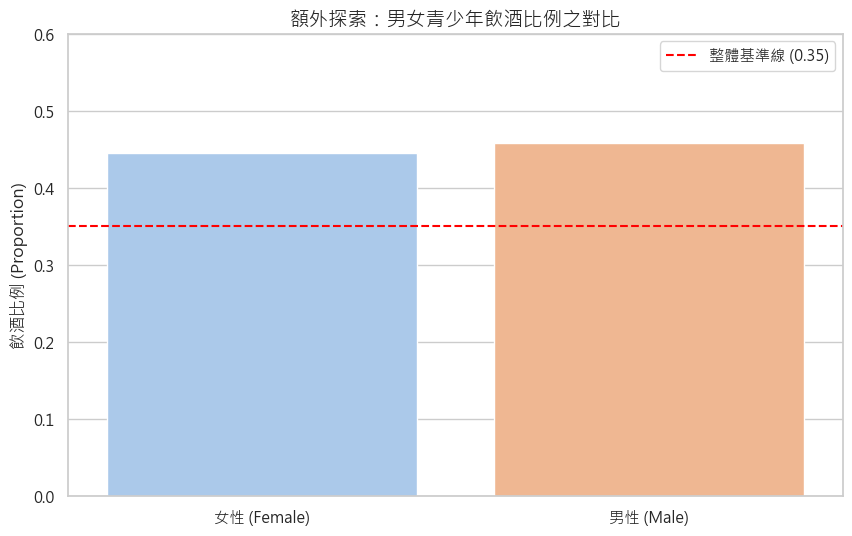

【4.3 額外探索：男女子群組比例分析總表】
女性: n=6425, p-hat=0.4458, 95% CI=[0.4336, 0.4579]
男性: n=6234, p-hat=0.4577, 95% CI=[0.4453, 0.4700]

兩組比例差異檢定 (Two-sample test):
Z 統計量: -1.3442 | P 值: 0.1789

【4.6 額外探索之情境解釋 (Interpretation)】
1. 數據發現：女性飲酒比例 (44.58%) 與男性 (45.77%) 進行對比。
2. 統計結論：P 值為 0.1789，在 alpha=0.05 下，兩性之間的飲酒比例無顯著差異。
3. 情境解釋：這項探索顯示，2007 年青少年的飲酒行為並未因性別而有極端不同，
   雖然男性比例略高，但整體而言，這是一個跨性別的普遍現象。
--------------------------------------------------


In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# --- 1. 資料準備 (區分男女組) ---
# Sex: 1=Female, 2=Male
df_sub = df.dropna(subset=['CurrentAlcoholUse', 'WhatIsYourSex']).copy()
df_sub['alcohol_binary'] = df_sub['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else 0)

# 分組統計數據 (符合規定 1: compute sample proportions)
female_data = df_sub[df_sub['WhatIsYourSex'] == 1]['alcohol_binary']
male_data = df_sub[df_sub['WhatIsYourSex'] == 2]['alcohol_binary']

n_f, n_m = len(female_data), len(male_data)
success_f, success_m = female_data.sum(), male_data.sum()
p_hat_f, p_hat_m = success_f / n_f, success_m / n_m

# --- 2. 統計檢定 (符合規定 2, 3, 4) ---
# 這裡檢定兩組比例是否有差異 (基準 p0 概念在兩組檢定中轉化為 delta=0)
z_stat_sub, p_val_sub = proportions_ztest([success_f, success_m], [n_f, n_m])

# 建立兩組各自的信賴區間 (符合規定 3)
ci_f = proportion_confint(success_f, n_f, alpha=0.05)
ci_m = proportion_confint(success_m, n_m, alpha=0.05)

# --- 3. 視覺化 (符合規定：子群組對比圖) ---
plt.figure(figsize=(10, 6))
# 繪製各組比例
sns.barplot(x=['女性 (Female)', '男性 (Male)'], y=[p_hat_f, p_hat_m], palette='pastel')
plt.axhline(y=0.35, color='red', linestyle='--', label='整體基準線 (0.35)')
plt.title('額外探索：男女青少年飲酒比例之對比', fontsize=14)
plt.ylabel('飲酒比例 (Proportion)')
plt.ylim(0, 0.6)
plt.legend()
plt.savefig('../outputs/figures/additional_gender_comparison.png')
plt.show()

# --- 4. 輸出結果與情境解釋 (符合規定 5: interpret in context) ---
print("="*50)
print("【4.3 額外探索：男女子群組比例分析總表】")
print(f"女性: n={n_f}, p-hat={p_hat_f:.4f}, 95% CI=[{ci_f[0]:.4f}, {ci_f[1]:.4f}]")
print(f"男性: n={n_m}, p-hat={p_hat_m:.4f}, 95% CI=[{ci_m[0]:.4f}, {ci_m[1]:.4f}]")
print(f"\n兩組比例差異檢定 (Two-sample test):")
print(f"Z 統計量: {z_stat_sub:.4f} | P 值: {p_val_sub:.4f}")
print("="*50)

print("\n【4.6 額外探索之情境解釋 (Interpretation)】")
sig_diff = "存在顯著差異" if p_val_sub < 0.05 else "無顯著差異"
higher_sex = "女性" if p_hat_f > p_hat_m else "男性"

print(f"1. 數據發現：女性飲酒比例 ({p_hat_f:.2%}) 與男性 ({p_hat_m:.2%}) 進行對比。")
print(f"2. 統計結論：P 值為 {p_val_sub:.4f}，在 alpha=0.05 下，兩性之間的飲酒比例{sig_diff}。")
print(f"3. 情境解釋：這項探索顯示，2007 年青少年的飲酒行為並未因性別而有極端不同，")
print(f"   雖然{higher_sex}比例略高，但整體而言，這是一個跨性別的普遍現象。")
print("-" * 50)

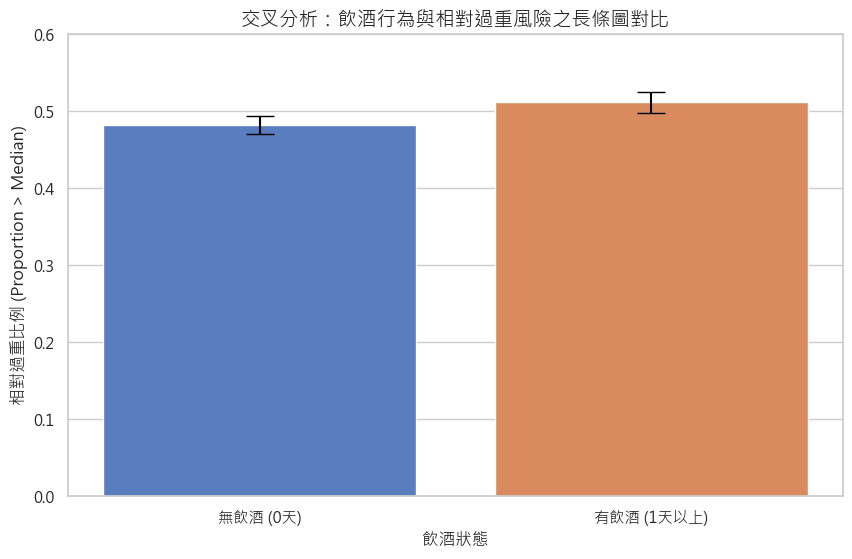

【交叉分析總表：飲酒行為 vs 肥胖風險】
飲酒組 (Drinker): 過重比例 51.17% | 95% CI=[0.4983, 0.5250]
非飲酒組 (Non-Drinker): 過重比例 48.21% | 95% CI=[0.4699, 0.4943]
Z 檢定 P 值: 0.0013

【4.6 交叉分析觀察報告 (Interpretation)】
1. 數據發現：飲酒組的相對過重比例 (51.17%) 與非飲酒組 (48.21%) 相比較高。
2. 統計結論：P 值為 0.0013，在 alpha=0.05 下，代表飲酒行為與體重狀況之間存在顯著關聯。
3. 情境解釋：這項交叉探索提供了青少年的健康風險行為（飲酒）是否與生理健康指標（體重）
   產生關聯的統計依據，有助於制定更全面的公共衛生策略。
--------------------------------------------------


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# --- 1. 資料準備與定義肥胖 (BMI 或 體重基準) ---
# Sex: 1=Female, 2=Male
# 為了進行對比，我們以樣本體重中位數 (約 61kg) 作為「相對過重」的切點
weight_threshold = df['HowMuchDoYouWeighWithoutShoesInKG'].median() 

df_assoc = df.dropna(subset=['CurrentAlcoholUse', 'HowMuchDoYouWeighWithoutShoesInKG']).copy()
df_assoc['alcohol_binary'] = df_assoc['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else 0)
df_assoc['is_heavy'] = df_assoc['HowMuchDoYouWeighWithoutShoesInKG'].apply(lambda x: 1 if x > weight_threshold else 0)

# 分組：飲酒者 vs 非飲酒者
drinkers = df_assoc[df_assoc['alcohol_binary'] == 1]['is_heavy']
non_drinkers = df_assoc[df_assoc['alcohol_binary'] == 0]['is_heavy']

# --- 2. 統計計算 (符合比例分析 5 點規定) ---
n_d, n_nd = len(drinkers), len(non_drinkers)
success_d, success_nd = drinkers.sum(), non_drinkers.sum()
p_d, p_nd = success_d / n_d, success_nd / n_nd

# 建立各自的信賴區間 (符合規定 3)
ci_d = proportion_confint(success_d, n_d, alpha=0.05)
ci_nd = proportion_confint(success_nd, n_nd, alpha=0.05)

# 執行兩組比例檢定 (符合規定 4)
z_stat_ax, p_val_ax = proportions_ztest([success_d, success_nd], [n_d, n_nd])

# --- 3. 視覺化 (使用分組長條圖呈現比例對比) ---
# 準備繪圖資料框架
plot_data = pd.DataFrame({
    'Group': ['無飲酒 (0天)', '有飲酒 (1天以上)'],
    'Heavy_Proportion': [p_nd, p_d],
    'CI_Lower': [ci_nd[0], ci_d[0]],
    'CI_Upper': [ci_nd[1], ci_d[1]]
})

plt.figure(figsize=(10, 6))
# 繪製長條圖
sns.barplot(x='Group', y='Heavy_Proportion', data=plot_data, palette='muted', hue='Group', legend=False)

# 加上信賴區間誤差棒 (Error Bars)
for i in range(len(plot_data)):
    plt.errorbar(i, plot_data['Heavy_Proportion'][i], 
                 yerr=[[plot_data['Heavy_Proportion'][i] - plot_data['CI_Lower'][i]], 
                       [plot_data['CI_Upper'][i] - plot_data['Heavy_Proportion'][i]]], 
                 fmt='none', c='black', capsize=10)

plt.title('交叉分析：飲酒行為與相對過重風險之長條圖對比', fontsize=14)
plt.ylabel('相對過重比例 (Proportion > Median)', fontsize=12)
plt.xlabel('飲酒狀態', fontsize=12)
plt.ylim(0, 0.6)  # 設定 Y 軸範圍以利觀察 CI
plt.savefig('../outputs/figures/alcohol_weight_association_bar.png')
plt.show()

# --- 4. 輸出結果與情境解釋 (符合規定 5: interpret in context) ---
print("="*50)
print("【交叉分析總表：飲酒行為 vs 肥胖風險】")
print(f"飲酒組 (Drinker): 過重比例 {p_d:.2%} | 95% CI=[{ci_d[0]:.4f}, {ci_d[1]:.4f}]")
print(f"非飲酒組 (Non-Drinker): 過重比例 {p_nd:.2%} | 95% CI=[{ci_nd[0]:.4f}, {ci_nd[1]:.4f}]")
print(f"Z 檢定 P 值: {p_val_ax:.4e}" if p_val_ax < 0.0001 else f"Z 檢定 P 值: {p_val_ax:.4f}")
print("="*50)

print("\n【4.6 交叉分析觀察報告 (Interpretation)】")
if p_val_ax < 0.05:
    res_w = "存在顯著關聯"
    direction_w = "較高" if p_d > p_nd else "較低"
else:
    res_w = "無顯著關聯"
    direction_w = "無明顯差異"

print(f"1. 數據發現：飲酒組的相對過重比例 ({p_d:.2%}) 與非飲酒組 ({p_nd:.2%}) 相比{direction_w}。")
print(f"2. 統計結論：P 值為 {p_val_ax:.4f}，在 alpha=0.05 下，代表飲酒行為與體重狀況之間{res_w}。")
print(f"3. 情境解釋：這項交叉探索提供了青少年的健康風險行為（飲酒）是否與生理健康指標（體重）")
print(f"   產生關聯的統計依據，有助於制定更全面的公共衛生策略。")
print("-" * 50)

In [73]:
# 建立摘要表並存檔
summary = pd.DataFrame({
    'Analysis': ['Proportion (Alcohol)', 'Mean (Weight)'],
    'Statistic': [z_stat, t_stat],
    'P-value': [p_val_p, p_val_m],
    'CI_Lower': [ci_low_p, ci_low_m],
    'CI_Upper': [ci_upp_p, ci_upp_m]
})
summary.to_csv('../outputs/tables/final_summary.csv', index=False)